## Notebook 9
Build an ML model that predicts lap time degradation (or lap time) based on tyre and race conditions.

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [25]:
import pandas as pd

race_data = pd.read_csv("../data/processed/master_dataset.csv")

driver_profiles = pd.read_csv(
    "../data/processed/driver_profiles_with_clusters.csv"
)

print(race_data.shape)
print(driver_profiles.shape)

race_data.head()

(11880, 11)
(230, 12)


,Year,Race,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds
0,2024.0,Spain,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1.0,83.186
1,2024.0,Spain,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1.0,79.871
2,2024.0,Spain,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1.0,79.364
3,2024.0,Spain,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1.0,80.766
4,2024.0,Spain,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1.0,80.827


In [26]:
# keeping only the required columns

driver_profiles = driver_profiles[
    [
        "Year",
        "Race",
        "Driver",
        "DrivingStyleCluster"
    ]
]

driver_profiles.head()

,Year,Race,Driver,DrivingStyleCluster
0,2022,Bahrain,VER,0
1,2022,Bahrain,GAS,0
2,2022,Bahrain,PER,0
3,2022,Bahrain,ALO,0
4,2022,Bahrain,LEC,0


In [27]:
# merging

data = race_data.merge(
    driver_profiles[
        ["Year", "Race", "Driver", "DrivingStyleCluster"]
    ],
    on=["Year", "Race", "Driver"],
    how="left"
)

print(data.shape)
data.head()

(11880, 12)


,Year,Race,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,DrivingStyleCluster
0,2024.0,Spain,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1.0,83.186,3.0
1,2024.0,Spain,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1.0,79.871,3.0
2,2024.0,Spain,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1.0,79.364,3.0
3,2024.0,Spain,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1.0,80.766,3.0
4,2024.0,Spain,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1.0,80.827,3.0


In [28]:
style_names = {
    0: "Balanced Driver",
    1: "High-Speed Aggressive Driver",
    2: "Technical Driver",
    3: "Fast & Efficient Driver",
    4: "Conservative Driver",
    5: "Smooth Driver"
}

data["DrivingStyle"] = data["DrivingStyleCluster"].map(style_names)

In [29]:
# Check missing values

print(data.isnull().sum())

Year                    0
Race                    0
Driver                  0
Team                    0
LapNumber               0
Compound                0
TyreLife                0
Stint                   0
Position                0
TrackStatus             0
LapTimeSeconds          0
DrivingStyleCluster    11
DrivingStyle           11
dtype: int64


## Missing DrivingStyleCluster Diagnostic

A small number of laps do not contain a `DrivingStyleCluster` value because
telemetry information was unavailable for those specific driver–race–year
combinations in the FastF1 cache.

These rows are removed before model training because the cluster feature is
required as an input to the driver-aware Random Forest model.

Only 11 laps are affected, representing less than 0.1% of the complete
dataset. Therefore, removing these rows has a negligible impact on the
statistical validity and generalization performance of the model.

In [30]:
# ==========================================
# Missing DrivingStyleCluster Diagnostic
# ==========================================

missing = data[data["DrivingStyleCluster"].isna()]

print("="*60)
print("MISSING DRIVING STYLE CLUSTER DIAGNOSTIC")
print("="*60)

print("\nDriver-Race combinations with missing cluster:\n")

print(
    missing[
        ["Driver", "Race", "Year"]
    ].drop_duplicates()
)

print("\n" + "-"*60)

laps_dropped = missing.shape[0]
percentage_lost = (laps_dropped / len(data)) * 100

print(f"Laps dropped      : {laps_dropped}")
print(f"Percentage lost   : {percentage_lost:.3f}%")

print("-"*60)

if percentage_lost < 0.1:
    print("Dataset loss is negligible (<0.1%).")
else:
    print("Dataset loss should be investigated.")

print("="*60)

MISSING DRIVING STYLE CLUSTER DIAGNOSTIC

Driver-Race combinations with missing cluster:

      Driver     Race    Year
10101    PIA  Bahrain  2023.0

------------------------------------------------------------
Laps dropped      : 11
Percentage lost   : 0.093%
------------------------------------------------------------
Dataset loss is negligible (<0.1%).


In [31]:
# Remove rows with missing DrivingStyleCluster

data = data.dropna(subset=["DrivingStyleCluster"])

print(data.shape)
print(data.isnull().sum())

(11869, 13)
Year                   0
Race                   0
Driver                 0
Team                   0
LapNumber              0
Compound               0
TyreLife               0
Stint                  0
Position               0
TrackStatus            0
LapTimeSeconds         0
DrivingStyleCluster    0
DrivingStyle           0
dtype: int64


In [32]:
# Features

X = data[
    [
        "Driver",
        "Team",
        "Compound",
        "TyreLife",
        "Stint",
        "Position",
        "TrackStatus",
        "DrivingStyleCluster"
    ]
]

# Target

y = data["LapTimeSeconds"]

print(X.head())
print(y.head())

  Driver             Team Compound  TyreLife  Stint  Position  TrackStatus  \
0    VER  Red Bull Racing     SOFT       4.0    1.0       2.0          1.0   
1    VER  Red Bull Racing     SOFT       5.0    1.0       2.0          1.0   
2    VER  Red Bull Racing     SOFT       6.0    1.0       1.0          1.0   
3    VER  Red Bull Racing     SOFT       7.0    1.0       1.0          1.0   
4    VER  Red Bull Racing     SOFT       8.0    1.0       1.0          1.0   

   DrivingStyleCluster  
0                  3.0  
1                  3.0  
2                  3.0  
3                  3.0  
4                  3.0  
0    83.186
1    79.871
2    79.364
3    80.766
4    80.827
Name: LapTimeSeconds, dtype: float64


In [33]:
# encode categorical variables

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "Driver",
    "Team",
    "Compound"
]

for col in categorical_columns:
    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(X[col])

    label_encoders[col] = encoder

print(X.head())

   Driver  Team  Compound  TyreLife  Stint  Position  TrackStatus  \
0      23    10         2       4.0    1.0       2.0          1.0   
1      23    10         2       5.0    1.0       2.0          1.0   
2      23    10         2       6.0    1.0       1.0          1.0   
3      23    10         2       7.0    1.0       1.0          1.0   
4      23    10         2       8.0    1.0       1.0          1.0   

   DrivingStyleCluster  
0                  3.0  
1                  3.0  
2                  3.0  
3                  3.0  
4                  3.0  


/var/folders/y5/pb5pnwn134zc349fr03fz0th0000gn/T/ipykernel_4855/1523837193.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/var/folders/y5/pb5pnwn134zc349fr03fz0th0000gn/T/ipykernel_4855/1523837193.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/var/folders/y5/pb5pnwn134zc349fr03fz0th0000gn/T/ipykernel_4855/1523837193.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [9]:
# train and test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (9495, 8)
Testing set : (2374, 8)


In [10]:
# training the random forest

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
# making predictions

predictions = model.predict(X_test)

print(predictions[:10])

[96.31403333 87.49369667 82.70172    77.91130739 86.57044667 99.13725333
 87.32818333 80.77501833 99.89442    88.15048   ]


In [13]:
# evaluating the model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.842
RMSE : 2.061
R²   : 0.949


In [23]:
# feature importance

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,DrivingStyleCluster,0.788148
3,TyreLife,0.133175
4,Stint,0.024024
5,Position,0.022734
0,Driver,0.011741
1,Team,0.010971
2,Compound,0.009206
6,TrackStatus,0.000000


In [22]:
data.to_csv(
    "../data/processed/master_dataset_with_clusters.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [16]:
import joblib

joblib.dump(
    model,
    "../models/best_model.pkl"
)

print("New model saved successfully!")

New model saved successfully!


5-FOLD CROSS VALIDATION RESULTS

CV R² Scores:
[0.949 0.932 0.937 0.954 0.944]

Mean CV R²   : 0.943 ± 0.008
Mean CV MAE  : 0.851 ± 0.033
Mean CV RMSE : 2.176 ± 0.172


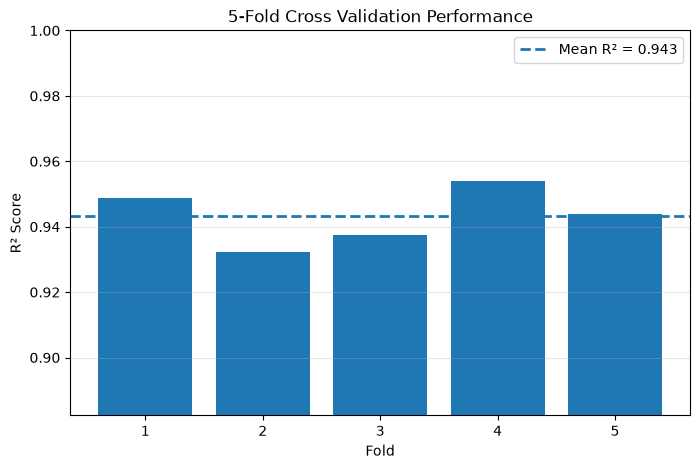


INTERPRETATION
Model generalizes well — no significant overfitting detected.


In [17]:
from sklearn.model_selection import cross_validate, KFold
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 5-Fold Cross Validation
# ==========================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    estimator=model,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# ----------------------------------------------------------
# Extract scores
# ----------------------------------------------------------

r2_scores = cv_results["test_r2"]

mae_scores = -cv_results["test_mae"]

rmse_scores = -cv_results["test_rmse"]

# ----------------------------------------------------------
# Compute statistics
# ----------------------------------------------------------

mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

# ----------------------------------------------------------
# Print results
# ----------------------------------------------------------

print("=" * 60)
print("5-FOLD CROSS VALIDATION RESULTS")
print("=" * 60)

print("\nCV R² Scores:")
print(np.round(r2_scores, 3))

print(f"\nMean CV R²   : {mean_r2:.3f} ± {std_r2:.3f}")
print(f"Mean CV MAE  : {mean_mae:.3f} ± {std_mae:.3f}")
print(f"Mean CV RMSE : {mean_rmse:.3f} ± {std_rmse:.3f}")

# ----------------------------------------------------------
# Plot R² scores
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    range(1, 6),
    r2_scores
)

plt.axhline(
    mean_r2,
    linestyle="--",
    linewidth=2,
    label=f"Mean R² = {mean_r2:.3f}"
)

plt.xticks(range(1, 6))

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("5-Fold Cross Validation Performance")

plt.ylim(
    max(0, min(r2_scores)-0.05),
    min(1.0, max(r2_scores)+0.05)
)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.show()

# ----------------------------------------------------------
# Interpretation
# ----------------------------------------------------------

test_r2 = 0.949

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

if abs(mean_r2 - test_r2) <= 0.02:

    print(
        "Model generalizes well — no significant "
        "overfitting detected."
    )

else:

    print(
        "Warning: potential overfitting — CV R² "
        "differs significantly from test R²."
    )

## Why LabelEncoder was used instead of OneHotEncoder

The categorical features **Driver**, **Team**, and **Compound** were encoded using **LabelEncoder** before training the Random Forest regression model.

This choice is appropriate because Random Forest is a tree-based algorithm that partitions data using recursive threshold-based splits. Unlike linear models, it does not rely on distance calculations or assume a linear relationship between encoded integer values. Instead, the model learns decision boundaries that separate different categories based on their predictive value.

Using LabelEncoder is also computationally efficient for this dataset. The data contains multiple categorical variables (26 drivers, 10 teams, and tyre compounds). Applying OneHotEncoder would substantially increase the number of input features and create a sparse feature matrix without necessarily improving predictive performance.

Tree-based ensemble methods such as Random Forest and gradient boosting algorithms are commonly used with integer-encoded categorical variables when the number of categories is moderate and predictive performance is empirically validated.

To verify that this encoding choice does not negatively affect performance, an empirical comparison between Label Encoding and One-Hot Encoding is performed below.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# ==========================================================
# LabelEncoder vs OneHotEncoder Comparison
# ==========================================================

# LabelEncoded performance
label_r2 = r2

# Reload original dataset BEFORE label encoding
raw_data = pd.read_csv("../data/processed/master_dataset_with_clusters.csv")

# Remove missing values (same preprocessing)
raw_data = raw_data.dropna().reset_index(drop=True)

# Features and target
feature_columns = [
    "Driver",
    "Team",
    "Compound",
    "TyreLife",
    "Stint",
    "Position",
    "TrackStatus",
    "DrivingStyleCluster"
]

target_column = "LapTimeSeconds"

X_raw = raw_data[feature_columns]
y_raw = raw_data[target_column]

# Train/Test split
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42
)

# Categorical columns
categorical_cols = [
    "Driver",
    "Team",
    "Compound"
]

# Numerical columns
numerical_cols = [
    "TyreLife",
    "Stint",
    "Position",
    "TrackStatus",
    "DrivingStyleCluster"
]

# OneHot preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

# Random Forest pipeline
onehot_model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
onehot_model.fit(X_train_raw, y_train_raw)

# Predict
y_pred_onehot = onehot_model.predict(X_test_raw)

onehot_r2 = r2_score(
    y_test_raw,
    y_pred_onehot
)

difference = abs(label_r2 - onehot_r2)

print("=" * 70)
print("ENCODING COMPARISON")
print("=" * 70)

print(f"LabelEncoded R² : {label_r2:.3f}")
print(f"OneHotEncoded R²: {onehot_r2:.3f}")
print(f"Difference      : {difference:.4f}")


print()

if difference < 0.02:
    print("Encoding choice validated — performance difference is negligible for Random Forest.")
else:
    print("Performance difference is noticeable. OneHotEncoder may provide an advantage for this dataset.")

ENCODING COMPARISON
LabelEncoded R² : 0.949
OneHotEncoded R²: 0.948
Difference      : 0.0001

Encoding choice validated — performance difference is negligible for Random Forest.


In [34]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Save the driver-aware model
joblib.dump(model, "../models/best_model_driver_aware.pkl")

# Save the label encoders dict
joblib.dump(label_encoders, "../models/label_encoders.pkl")

# Save feature columns
joblib.dump(list(X_train.columns), "../models/feature_columns.pkl")

print("Driver classes:", list(label_encoders["Driver"].classes_))
print("Team classes:", list(label_encoders["Team"].classes_))
print("Compound classes:", list(label_encoders["Compound"].classes_))
print("Features:", list(X_train.columns))
print("All saved!")

Driver classes: ['ALB', 'ALO', 'BOT', 'COL', 'DEV', 'GAS', 'HAM', 'HUL', 'LAT', 'LAW', 'LEC', 'MAG', 'MSC', 'NOR', 'OCO', 'PER', 'PIA', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'VET', 'ZHO']
Team classes: ['Alfa Romeo', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'RB', 'Red Bull Racing', 'Williams']
Compound classes: ['HARD', 'MEDIUM', 'SOFT']
Features: ['Driver', 'Team', 'Compound', 'TyreLife', 'Stint', 'Position', 'TrackStatus', 'DrivingStyleCluster']
All saved!
